Paquetes necesarios

In [2]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
import csv

Tarea 1

Se obtiene la imagen de las monedas, se convierte a grises y se umbraliza con Otsu

(938, 473, 3)
Umbral Otsu:  204.0


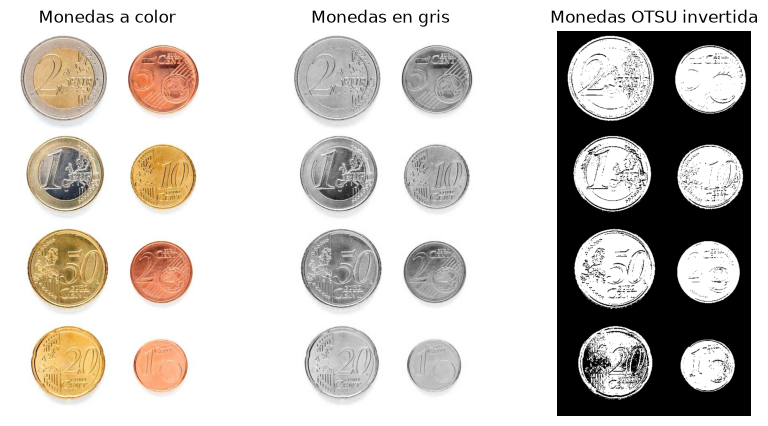

In [ ]:
money = cv2.imread('Monedas.jpg') 
print(money.shape)

money_rgb = cv2.cvtColor(money, cv2.COLOR_BGR2RGB)

money_gris = cv2.cvtColor(money, cv2.COLOR_BGR2GRAY)

th2,money_otsu = cv2.threshold(money_gris,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
print('Umbral Otsu: ', th2)

plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.title("Monedas a color")
plt.imshow(money_rgb)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Monedas en gris")
plt.imshow(money_gris, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.axis("off")
plt.imshow(money_otsu,cmap='gray') 
plt.title('Monedas OTSU invertida')

plt.show()

Se buscan sus contornos externos y se calcula el radio de cada moneda

Text(0.5, 1.0, 'Contornos externos de las monedas')

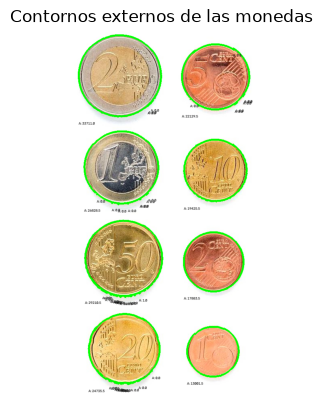

In [22]:
# Parámeros texto
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.3
thickness = 1
color = (0, 0, 0)

contornos, hierarchy = cv2.findContours(money_otsu, 
    cv2.RETR_EXTERNAL , 
    cv2.CHAIN_APPROX_SIMPLE)

#Dibuja sobre la imagen de entrada sólo contornos externos
money_rgb = cv2.cvtColor(money, cv2.COLOR_BGR2RGB)
cv2.drawContours(money_rgb, contornos, -1, (0,255,0), 3)

for contorno in contornos:
    area = cv2.contourArea(contorno)
    x,y,w,h = cv2.boundingRect(contorno)

    cv2.putText(money_rgb, f"A: {area:.1f}", (x, int(y+h+20)), font, font_scale, (0, 0, 0), thickness)

plt.axis("off")
plt.imshow(money_rgb) 
plt.title('Contornos externos de las monedas')